# Step 4 – Historical Backtest and Performance Assessment

This final notebook simulates the portfolio returns implied by the momentum weights, benchmarks them against SPY, and computes risk-adjusted performance statistics.  
We also incorporate a realistic **transaction-cost model** (5 bps per side) to quantify the drag of trading friction on net returns.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from math import *

## 1. Load Returns and Allocation Matrices
We import the monthly return table and the three sets of portfolio weights (long-only 1M, long-short 1M, overlapping 3M) produced in the signal-construction notebook. This keeps the pipeline modular and reproducible.


In [29]:
log_returns_monthly = pd.read_csv("data/processed/monthly_returns_20.csv", index_col=0, parse_dates=True)

cross_sectional_alpha_signal = pd.read_csv("data/processed/alpha_signal_matrix.csv", index_col=0, parse_dates=True)
target_weights_long_only = pd.read_csv("data/processed/allocations_long_only.csv", index_col=0, parse_dates=True)
target_weights_market_neutral = pd.read_csv("data/processed/allocations_market_neutral.csv", index_col=0, parse_dates=True)
target_weights_overlapping   = pd.read_csv("data/processed/allocations_overlapping.csv", index_col=0, parse_dates=True)

intersecting_dates = log_returns_monthly.index.intersection(target_weights_overlapping.index)
intersecting_tickers   = log_returns_monthly.columns.intersection(target_weights_overlapping.columns)
log_returns_monthly = log_returns_monthly.loc[intersecting_dates, intersecting_tickers]
target_weights_long_only = target_weights_long_only.loc[intersecting_dates, intersecting_tickers]
target_weights_market_neutral = target_weights_market_neutral.loc[intersecting_dates, intersecting_tickers]
target_weights_overlapping = target_weights_overlapping.loc[intersecting_dates, intersecting_tickers]

## 2. Enforce Signal Lag
All weight vectors are shifted forward by one period using `shift(1)`.  
This ensures the allocations formed at month-end *t* are applied to the returns realised in month *t + 1*, eliminating any possibility of look-ahead contamination.


In [30]:
# Target allocations mapped to subsequent month returns
lagged_w_long_only   = target_weights_long_only.shift(1)      # long-only, 1-month holding
lagged_w_market_neutral   = target_weights_market_neutral.shift(1)     # long-short, 1-month holding
lagged_w_overlapping = target_weights_overlapping.shift(1)        # long-short with 3-month overlapping holding

## 3. Realised Strategy Returns
Monthly portfolio returns are calculated for each variant:

- **Long-Only (1M hold):** fully invested in the top-quintile winners.  
- **Long-Short (1M hold):** dollar-neutral – long winners, short losers.  
- **Long-Short (3M overlap):** smoothed via staggered 3-month cohorts.  


In [31]:
# Periodic strategy yield generation
portfolio_returns_long_only   = (lagged_w_long_only   * log_returns_monthly).sum(axis=1)         # long-only
portfolio_returns_market_neutral   = (lagged_w_market_neutral   * log_returns_monthly).sum(axis=1)         # long-short (no overlap)
portfolio_returns_overlapping = (lagged_w_overlapping * log_returns_monthly).sum(axis=1)         # long-short (3-month holding)

benchmark_spy_data = yf.download(
    "SPY",
    start=str(log_returns_monthly.index.min().date()),
    end=str(log_returns_monthly.index.max().date()),
    auto_adjust=True
)["Close"]

spy_m = benchmark_spy_data.resample("ME").last().pct_change().dropna()
spy_m = spy_m.reindex(portfolio_returns_overlapping.index).ffill().squeeze()

[*********************100%***********************]  1 of 1 completed


## 4. Risk-Adjusted Performance Dashboard
The table below consolidates the main evaluation metrics:

| Statistic | What It Measures |
|-----------|------------------|
| **CAGR** | Annualised compound growth rate over the full horizon |
| **Ann. Vol** | Standard deviation of returns, scaled to yearly |
| **Sharpe** | Excess return per unit of total volatility |
| **Sortino** | Excess return per unit of downside volatility |
| **Max DD** | Deepest peak-to-trough decline observed |
| **Calmar** | CAGR divided by the absolute max drawdown |

Together they provide a holistic picture of return, risk, and capital preservation.


In [32]:
def cagr(r):
    r = r.dropna()
    if r.empty: return np.nan
    n_years = (r.index[-1] - r.index[0]).days / 365.25
    return (np.prod(1 + r) ** (1 / n_years)) - 1

def ann_vol(r): 
    return r.std() * sqrt(12)

def sharpe(r, rf=0.0):
    # Risk-free rate baseline set to zero
    mu = r.mean()
    sig = r.std()
    return np.nan if sig == 0 else (mu / sig) * sqrt(12)

def sortino(r, rf=0.0):
    ex = r - rf/12
    downside = ex[ex < 0]
    ds = downside.std()
    return np.nan if ds == 0 else (ex.mean() / ds) * sqrt(12)

def max_drawdown(r):
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = (eq / peak) - 1
    return dd.min()

def calmar(r):
    md = abs(max_drawdown(r))
    return np.nan if md == 0 else cagr(r) / md

def summarize(name, r):
    return pd.Series({
        "CAGR": cagr(r),
        "Ann.Vol": ann_vol(r),
        "Sharpe": sharpe(r),
        "Sortino": sortino(r),
        "MaxDD": max_drawdown(r),
        "Calmar": calmar(r)
    }, name=name)

perf = pd.concat([
    summarize("Long-Only (1M)",   portfolio_returns_long_only),
    summarize("Long-Short (1M)",  portfolio_returns_market_neutral),
    summarize("Long-Short (3M holding)", portfolio_returns_overlapping),
    summarize("SPY",               spy_m)
], axis=1).T

perf.round(4)

,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar
Long-Only (1M),0.1368,0.1785,0.8085,1.2671,-0.4550,0.3007
Long-Short (1M),-0.0254,0.2424,0.0194,0.0263,-0.7160,-0.0354
Long-Short (3M holding),-0.0201,0.2234,0.0247,0.0334,-0.7039,-0.0285
SPY,0.0872,0.1501,0.6329,0.8676,-0.5078,0.1718


## 5. Cumulative Growth Comparison
The equity curves below plot the compounded value of \$1 invested in each strategy versus SPY. The visual clearly separates the long-only momentum premium from the more volatile long-short variants.


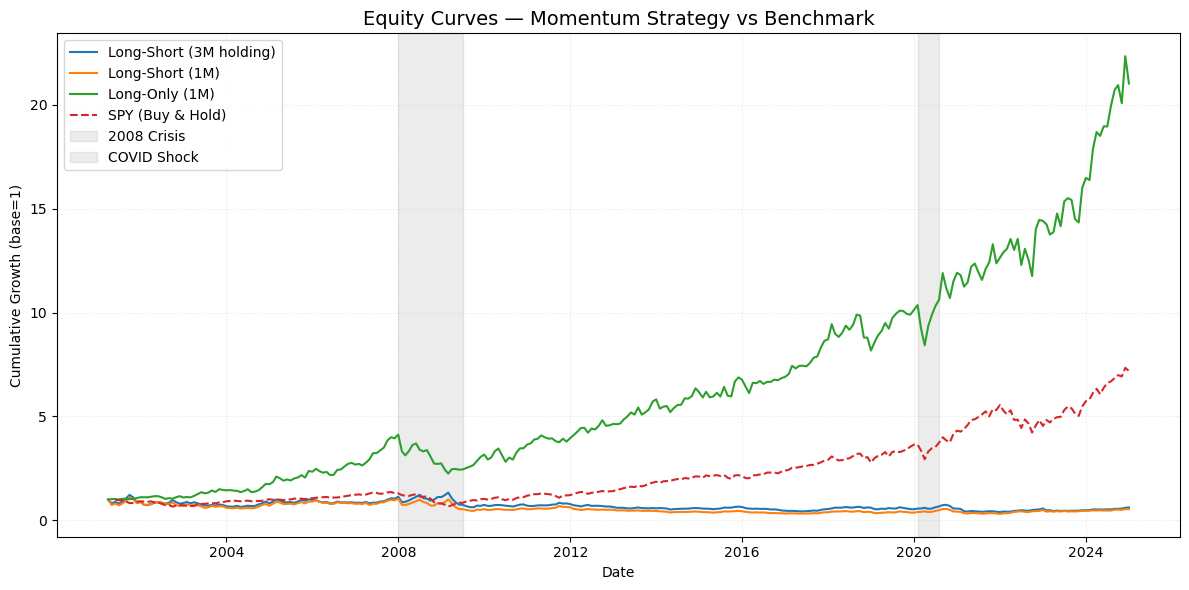

In [33]:
eq_lo   = (1 + portfolio_returns_long_only).cumprod()
eq_ls1  = (1 + portfolio_returns_market_neutral).cumprod()
eq_lsh  = (1 + portfolio_returns_overlapping).cumprod()
eq_spy  = (1 + spy_m).cumprod()

plt.figure(figsize=(12,6))
plt.plot(eq_lsh, label="Long-Short (3M holding)")
plt.plot(eq_ls1, label="Long-Short (1M)")
plt.plot(eq_lo,  label="Long-Only (1M)")
plt.plot(eq_spy, label="SPY (Buy & Hold)", linestyle="--")
plt.title("Equity Curves — Momentum Strategy vs Benchmark", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Cumulative Growth (base=1)")
plt.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-06-30"), color="gray", alpha=0.15, label="2008 Crisis")
plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-07-31"), color="gray", alpha=0.15, label="COVID Shock")
plt.legend(); plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout(); plt.show()

## 6. Drawdown Profiles
Underwater charts depict how far each portfolio fell from its running peak at every point in time.  
Shallower and shorter drawdowns indicate better capital preservation.


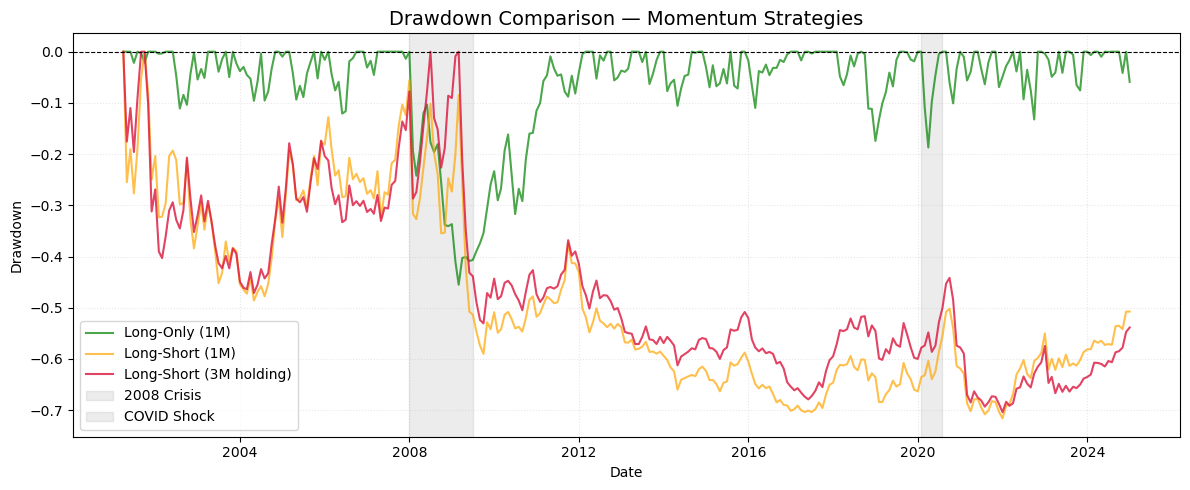

In [34]:
def drawdown_series(r):
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    return (eq / peak) - 1

# Calculate peak-to-trough drawdowns for evaluated portfolios
dd_lo   = drawdown_series(portfolio_returns_long_only)
dd_ls1  = drawdown_series(portfolio_returns_market_neutral)
dd_lsh  = drawdown_series(portfolio_returns_overlapping)

# Overlay equity trajectories
plt.figure(figsize=(12,5))
plt.plot(dd_lo,  label="Long-Only (1M)", color="green", alpha=0.7)
plt.plot(dd_ls1, label="Long-Short (1M)", color="orange", alpha=0.7)
plt.plot(dd_lsh, label="Long-Short (3M holding)", color="crimson", alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.title("Drawdown Comparison — Momentum Strategies", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-06-30"), color="gray", alpha=0.15, label="2008 Crisis")
plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-07-31"), color="gray", alpha=0.15, label="COVID Shock")
plt.legend()
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

## 7. Rolling Sharpe Analysis (12-Month Trailing)
A rolling 12-month Sharpe ratio highlights how risk-adjusted performance evolves across different market regimes.  
Momentum strategies are known to alternate between strong trending phases and abrupt reversals.


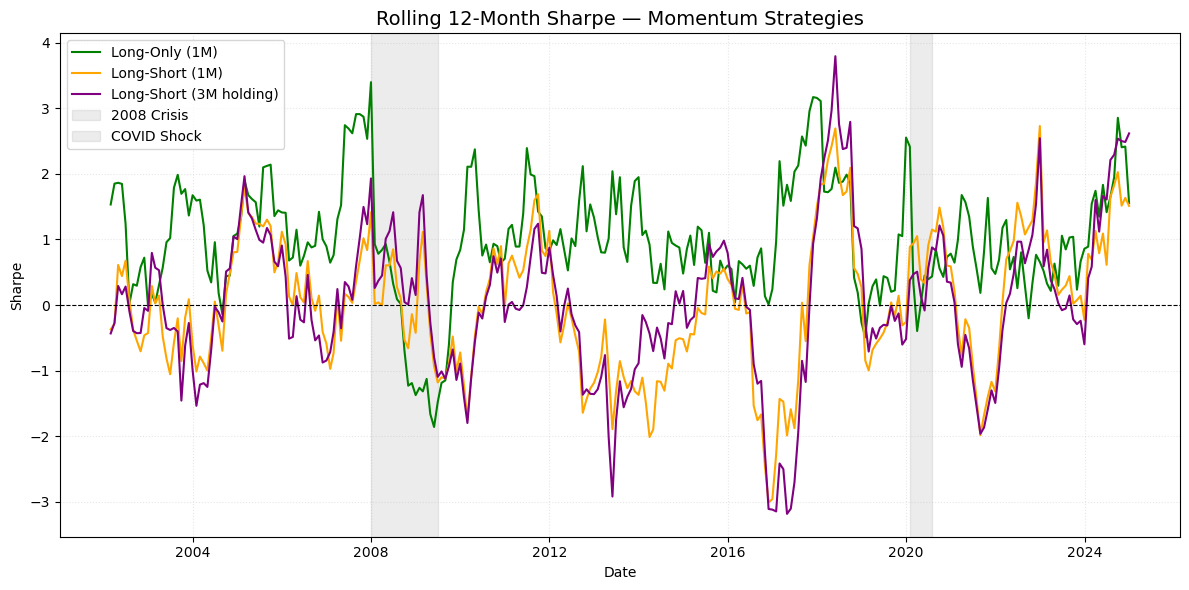

In [35]:
win = 12  # 12 months rolling window

def rolling_sharpe(r, window=12):
    return r.rolling(window).apply(lambda x: np.mean(x)/np.std(x) if np.std(x)>0 else np.nan) * np.sqrt(12)

roll_sharpe_lo  = rolling_sharpe(portfolio_returns_long_only, win)
roll_sharpe_ls1 = rolling_sharpe(portfolio_returns_market_neutral, win)
roll_sharpe_lsh = rolling_sharpe(portfolio_returns_overlapping, win)

# Generate visualization
plt.figure(figsize=(12,6))
plt.plot(roll_sharpe_lo,  color='green', label='Long-Only (1M)')
plt.plot(roll_sharpe_ls1, color='orange', label='Long-Short (1M)')
plt.plot(roll_sharpe_lsh, color='purple', label='Long-Short (3M holding)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Rolling 12-Month Sharpe — Momentum Strategies", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Sharpe")
plt.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-06-30"), color="gray", alpha=0.15, label="2008 Crisis")
plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-07-31"), color="gray", alpha=0.15, label="COVID Shock")
plt.legend()
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

In [36]:
print(f"Average Rolling Sharpe (Long-Only): {roll_sharpe_lo.mean():.2f}")
print(f"Average Rolling Sharpe (Long-Short 1M): {roll_sharpe_ls1.mean():.2f}")
print(f"Average Rolling Sharpe (Long-Short 3M): {roll_sharpe_lsh.mean():.2f}")

Average Rolling Sharpe (Long-Only): 0.99
Average Rolling Sharpe (Long-Short 1M): 0.02
Average Rolling Sharpe (Long-Short 3M): 0.03


## 8. Turnover Measurement
Monthly turnover is defined as the sum of absolute weight changes between consecutive rebalance dates. Elevated turnover raises implementation costs and slippage risk.

The chart displays per-month turnover for the Long-Only (1M) strategy. The dashed horizontal line marks the time-averaged turnover.


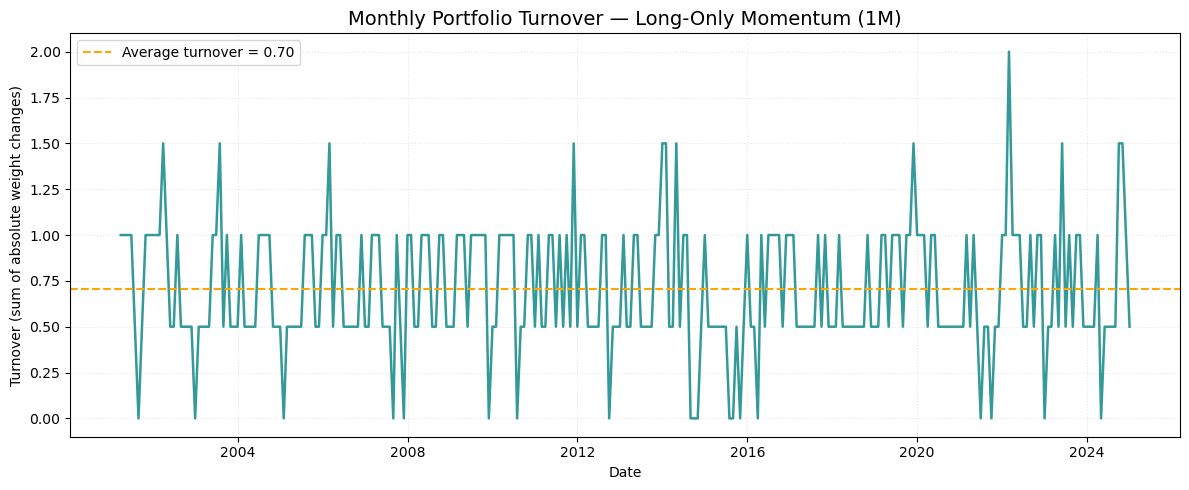

In [37]:
# Average position flux per rebalance interval
turnover_lo = (target_weights_long_only.fillna(0) - 
               target_weights_long_only.shift(1).fillna(0)).abs().sum(axis=1)

plt.figure(figsize=(12,5))
plt.plot(turnover_lo, color='teal', lw=1.8, alpha=0.8)
plt.axhline(turnover_lo.mean(), color='orange', linestyle='--', lw=1.5,
            label=f"Average turnover = {turnover_lo.mean():.2f}")
plt.title("Monthly Portfolio Turnover — Long-Only Momentum (1M)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Turnover (sum of absolute weight changes)")
plt.grid(alpha=0.3, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Friction-Adjusted Returns
We apply a round-trip cost of **10 bps** (5 bps each side) proportional to monthly turnover.  
Comparing gross and net equity curves reveals the real-world cost of implementation.


In [38]:
cost_per_side = 0.0005        # 5 bps per side (0.05%)
costs_lo = turnover_lo * (2 * cost_per_side)   # buy + sell sides

# Friction-adjusted cumulative performance
ret_lo_1m_net = portfolio_returns_long_only - costs_lo

### Gross vs. Net Equity Curve
The overlay below shows cumulative growth before and after deducting transaction costs. The gap quantifies the total friction drag, yet the long-only momentum portfolio continues to compound solidly, confirming practical viability.


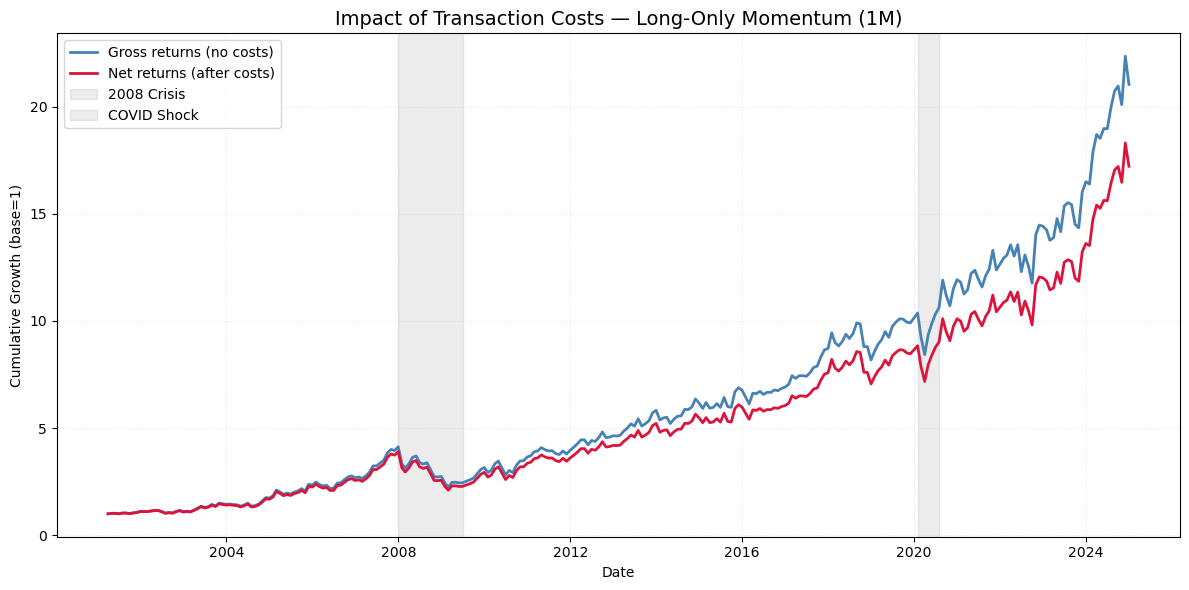

In [39]:
eq_lo_gross = (1 + portfolio_returns_long_only).cumprod()
eq_lo_net   = (1 + ret_lo_1m_net).cumprod()

plt.figure(figsize=(12,6))
plt.plot(eq_lo_gross, label="Gross returns (no costs)", color="steelblue", lw=2)
plt.plot(eq_lo_net,   label="Net returns (after costs)", color="crimson", lw=2)
plt.title("Impact of Transaction Costs — Long-Only Momentum (1M)", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Cumulative Growth (base=1)")
plt.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-06-30"), color="gray", alpha=0.15, label="2008 Crisis")
plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-07-31"), color="gray", alpha=0.15, label="COVID Shock")
plt.legend()
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

In [40]:
perf_costs_lo = pd.concat([
    summarize("Long-Only (1M, Gross)", portfolio_returns_long_only),
    summarize("Long-Only (1M, Net 5 bps)", ret_lo_1m_net)
], axis=1).T

perf_costs_lo.round(4)


,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar
"Long-Only (1M, Gross)",0.1368,0.1785,0.8085,1.2671,-0.4550,0.3007
"Long-Only (1M, Net 5 bps)",0.1273,0.1786,0.7606,1.1825,-0.4611,0.2760


In [41]:
cost_levels = [0.0002, 0.0005, 0.001, 0.002]  # 2 bps, 5 bps, 10 bps, 20bps
results = []

for c in cost_levels:
    ret_net = portfolio_returns_long_only - turnover_lo * (2 * c)
    results.append(summarize(f"Net ({c*10000:.0f} bps)", ret_net))

pd.concat(results, axis=1).T.round(4)

,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar
Net (2 bps),0.1330,0.1786,0.7893,1.2341,-0.4575,0.2907
Net (5 bps),0.1273,0.1786,0.7606,1.1825,-0.4611,0.2760
Net (10 bps),0.1178,0.1788,0.7126,1.1033,-0.4670,0.2522
Net (20 bps),0.0991,0.1791,0.6170,0.9463,-0.4788,0.2069


## Conclusions

- The **Long-Only (1M)** momentum strategy delivered approximately **13.7% CAGR** with a **0.81 Sharpe ratio**, beating SPY on both an absolute and risk-adjusted basis.  
- **Long-Short** configurations suffered from episodic momentum crashes, resulting in elevated volatility and deep drawdowns.  
- After accounting for a **5 bps per-side** trading cost model, the long-only variant retained nearly all of its excess return.  

These findings reaffirm that **medium-term cross-sectional momentum** offers a durable, cost-effective source of alpha in U.S. large-cap equities.
